# CSC 591 - IoT Analytics: Project 2
## Task 2 - Basic Statistics Analysis - Stage 2  
**Samples used for Task 2:** 100 

| Variable | NOAA Column | Description | Unit | Role |
|----------|-------------|-------------|------|------|
| X1 | TMAX | Maximum daily temperature | °F | Input |
| X2 | TMIN | Minimum daily temperature | °F | Input |
| X3 | PRCP | Daily precipitation | inches | Input |
| X4 | AWND | Average daily wind speed | mph | Input |
| X5 | SNOW | Daily snowfall | inches | Input |
| Y  | TAVG | Average daily temperature | °F | **Output** |

**Y = f(X1, X2, X3, X4, X5)**

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

#  Load & rename columns 
df_full = pd.read_csv('weather_clean.csv')
df = df_full.head(100).copy()

variables = ['X1', 'X2', 'X3', 'X4', 'X5']
labels = {
    'X1': 'TMAX — Max Temp (°F)',
    'X2': 'TMIN — Min Temp (°F)',
    'X3': 'PRCP — Precipitation (in)',
    'X4': 'AWND — Avg Wind Speed (mph)',
    'X5': 'SNOW — Snowfall (in)'
}

print(f'Task 2 sample size: {len(df)} rows')
print(f'Columns: {list(df.columns)}')
df.head()

Task 2 sample size: 100 rows
Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'Y']


,X1,X2,X3,X4,X5,Y
0,79,64,0.43,14.32,0.0,69.0
1,70,59,0.81,11.41,0.0,67.0
2,60,31,2.29,10.29,0.0,49.0
3,44,26,0.00,3.36,0.0,34.0
4,59,30,0.00,4.92,0.0,41.0



## Task 2.1 - Descriptive Statistics

Each statistic is computed step-by-step without calling `.describe()` 

In [3]:
# Compute each statistic individually 
results = {}

for col in variables:
    data = df[col]
    n    = len(data)

    # Mean: sum of all values divided by count
    mean = data.sum() / n

    # Median: middle value of sorted data
    sorted_d = data.sort_values().reset_index(drop=True)
    if n % 2 == 0:
        median = (sorted_d[n//2 - 1] + sorted_d[n//2]) / 2
    else:
        median = sorted_d[n//2]

    # Sample Variance: sum of squared deviations / (n-1)
    variance = sum((x - mean)**2 for x in data) / (n - 1)

    # Standard Deviation
    std_dev = variance ** 0.5

    # Range
    data_range = data.max() - data.min()

    # IQR = Q3 - Q1
    q1  = data.quantile(0.25)
    q3  = data.quantile(0.75)
    iqr = q3 - q1

    results[col] = {
        'mean': mean, 'median': median, 'variance': variance,
        'std': std_dev, 'min': data.min(), 'max': data.max(),
        'range': data_range, 'q1': q1, 'q3': q3, 'iqr': iqr
    }

# Print formatted table 
print(f"{'Stat':<12} {'X1':>10} {'X2':>10} {'X3':>10} {'X4':>10} {'X5':>10}")
print('─' * 62)
for stat in ['mean','median','variance','std','min','max','range','q1','q3','iqr']:
    row = f"{stat:<12}"
    for col in variables:
        row += f" {results[col][stat]:>10.4f}"
    print(row)

print('\n* mean computed as sum/n')
print('* median computed via sorted index')
print('* variance computed as Σ(xi - x̄)² / (n-1)  [sample variance]')
print('* IQR = Q3 - Q1')

Stat                 X1         X2         X3         X4         X5
──────────────────────────────────────────────────────────────
mean            60.4200    37.6000     0.1246     6.9905     0.0270
median          60.0000    35.0000     0.0000     6.4900     0.0000
variance       157.0743   148.8081     0.1010    11.7805     0.0301
std             12.5329    12.1987     0.3178     3.4323     0.1734
min             30.0000    15.0000     0.0000     1.5700     0.0000
max             84.0000    65.0000     2.2900    18.3400     1.5000
range           54.0000    50.0000     2.2900    16.7700     1.5000
q1              52.0000    28.0000     0.0000     4.2500     0.0000
q3              70.0000    46.0000     0.0525     8.3350     0.0000
iqr             18.0000    18.0000     0.0525     4.0850     0.0000

* mean computed as sum/n
* median computed via sorted index
* variance computed as Σ(xi - x̄)² / (n-1)  [sample variance]
* IQR = Q3 - Q1



## Task 2.2 - Probability Mass Function (PMF)

For each variable Xi:
- The range is divided into **50 equal intervals** from min to max
- Count of values falling in each bin is divided by total (n=100) to get probability
- Mean and median are overlaid as vertical reference lines

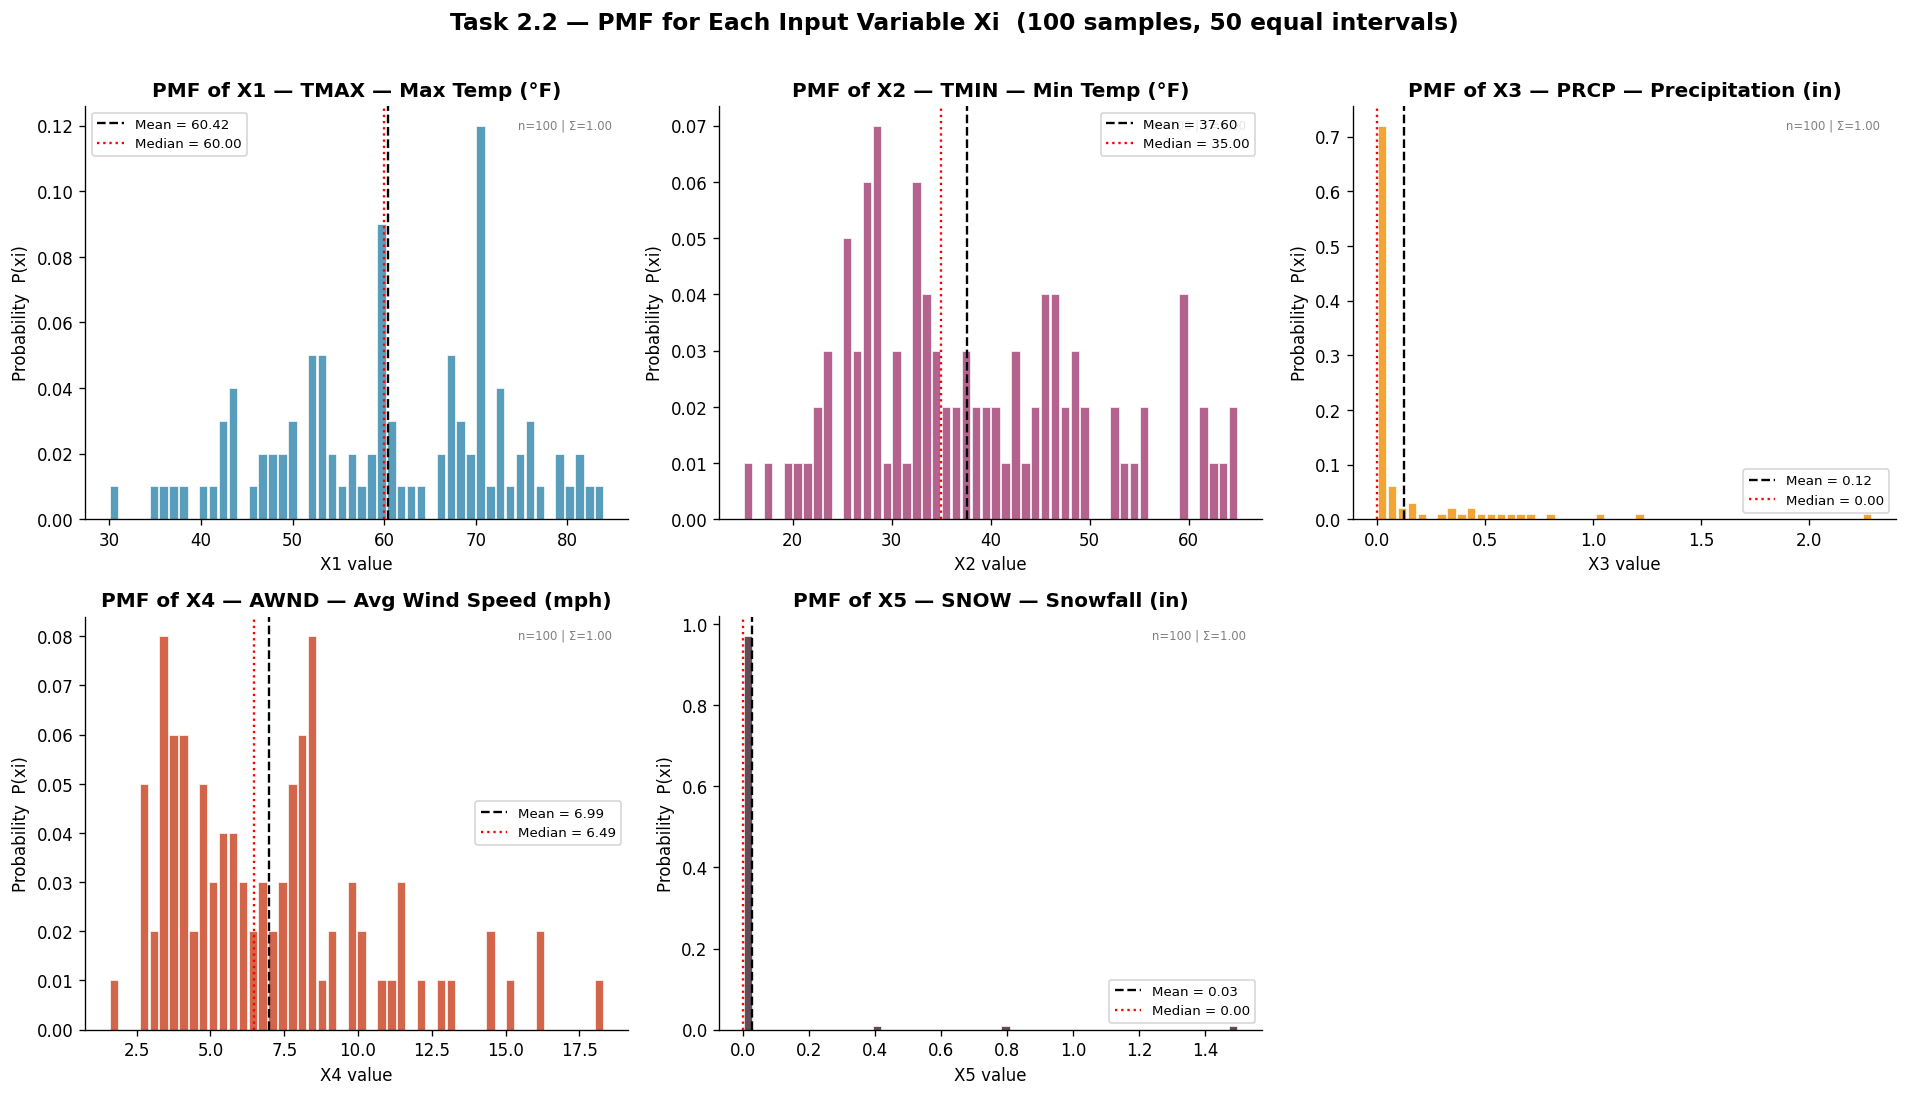

Saved: pmf_plots.png


In [3]:
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(variables):
    data = df[col]

    # 50 equal intervals: 51 edges spanning exactly min to max
    bins   = np.linspace(data.min(), data.max(), 51)
    counts, edges = np.histogram(data, bins=bins)
    pmf    = counts / counts.sum()          # normalize to probability
    centers = (edges[:-1] + edges[1:]) / 2 # bin center x-positions
    width   = edges[1] - edges[0]

    axes[i].bar(centers, pmf, width=width * 0.85,
                color=colors[i], alpha=0.80, edgecolor='white', linewidth=0.5)

    # Reference lines
    axes[i].axvline(results[col]['mean'],   color='black', linestyle='--',
                    linewidth=1.4, label=f"Mean = {results[col]['mean']:.2f}")
    axes[i].axvline(results[col]['median'], color='red',   linestyle=':',
                    linewidth=1.4, label=f"Median = {results[col]['median']:.2f}")

    axes[i].set_title(f'PMF of {col} — {labels[col]}', fontweight='bold')
    axes[i].set_xlabel(f'{col} value')
    axes[i].set_ylabel('Probability  P(xi)')
    axes[i].legend(fontsize=8)

    # Annotate bin count and sum check
    axes[i].text(0.97, 0.97, f'n=100 | Σ={pmf.sum():.2f}',
                 transform=axes[i].transAxes, fontsize=7,
                 ha='right', va='top', color='gray')

axes[5].set_visible(False)
fig.suptitle('Task 2.2 — PMF for Each Input Variable Xi  (100 samples, 50 equal intervals)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pmf_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pmf_plots.png')

## Task 2.3 - SOCS Analysis Report

### X1 - TMAX (Maximum Daily Temperature, °F)
**Stats: mean=60.42, median=60.00, variance=157.07, std=12.53, range=54, IQR=18, Q1=52, Q3=70**

**Shape:** The PMF of X1 shows a broad, right-skewed distribution. Since mean (60.42°F) is slightly above the median (60.00°F), the distribution has a mild right skew — a few warmer days pull the mean up. The 100-sample window covers January through early April, so the distribution captures the transition from winter cold (min=30°F) into early spring warmth (max=84°F), producing a wide, gradually rising shape rather than a sharp single peak.

**Outliers:** Using the IQR fence method: upper fence = Q3 + 1.5×IQR = 70 + 27 = **97°F**, lower fence = Q1 − 1.5×IQR = 52 − 27 = **25°F**. No values in X1 exceed either fence, meaning there are **no statistical outliers** in this variable. All values fall within physically expected seasonal bounds for Raleigh, NC.

**Center:** The mean (60.42°F) and median (60.00°F) are nearly identical, indicating that the center of the distribution is reliable and not distorted by extreme values. Both measures consistently point to approximately 60°F as the typical maximum daily temperature across this 100-day sample. This is consistent with the January-through-April period in Raleigh, where maxima rise gradually from the mid-30s to the low 80s.

**Spread:** X1 has the highest absolute spread of all variables: range = 54°F, IQR = 18°F, variance = 157.07. This high variability reflects the seasonal transition captured in the sample — early January days have TMAX in the 30s while late spring days reach the 80s. The large IQR of 18°F means that even the middle 50% of days span an 18-degree window, confirming that day-to-day temperature swings are substantial. X1's spread has the largest direct influence on Y (TAVG) given their near-perfect correlation.

---

### X2 — TMIN (Minimum Daily Temperature, °F)
**Stats: mean=37.60, median=35.00, variance=148.81, std=12.20, range=50, IQR=18, Q1=28, Q3=46**

**Shape:** X2 is right-skewed — the mean (37.60°F) is noticeably higher than the median (35.00°F). The PMF shows higher probability mass concentrated in the lower temperature bins (15–35°F), with a long right tail extending toward 65°F. This reflects the fact that most overnight lows during winter are cold, but seasonal progression and occasional warm spells push some TMIN values well above the winter baseline.

**Outliers:** Upper fence = Q3 + 1.5×IQR = 46 + 27 = **73°F**, lower fence = Q1 − 1.5×IQR = 28 − 27 = **1°F**. No values exceed either fence. The maximum value of 65°F is below the 73°F upper fence, and the minimum of 15°F is above the 1°F lower fence. Therefore, **no outliers** exist in X2. The wide range is entirely explained by normal seasonal variation.

**Center:** The mean (37.60°F) is 2.6°F above the median (35.00°F), confirming the right skew. The median is the more representative measure of a typical overnight low in this sample — it tells us that half of all nights had a TMIN at or below 35°F. The mean is pulled upward by the warmer nights in the spring portion of the sample. Together, mean and median indicate the sample is transitioning from cold winter nights toward milder spring nights.

**Spread:** X2 has range = 50°F, IQR = 18°F, variance = 148.81 — comparable to X1 but with greater absolute range. The overnight low varies widely across the season. The IQR of 18°F is relatively large, meaning even typical days show wide variation in overnight temperature. This high spread directly feeds into Y (TAVG) variability, as TMIN is the second-strongest predictor of average temperature (r = 0.97).

---

### X3 - PRCP (Precipitation, inches)
**Stats: mean=0.1246, median=0.0000, variance=0.1010, std=0.3178, range=2.29, IQR=0.0525, Q1=0, Q3=0.0525**

**Shape:** X3 has an extremely right-skewed, zero-inflated distribution. 68 out of 100 days (68%) had exactly zero precipitation, making the PMF dominated by a single spike at zero with a long right tail. This is characteristic of precipitation data globally — rainfall is episodic rather than continuous. The PMF's right tail shows a gradual decrease in probability as rainfall amount increases, with one extreme event at 2.29 inches.

**Outliers:** The upper fence = Q3 + 1.5×IQR = 0.0525 + 0.0788 = **0.1313 inches**. Any day with more than 0.1313 inches of rain is a statistical outlier. This produces **many outliers**: 2.29, 1.22, 1.01, 0.81, 0.72, 0.62, 0.43, 0.34 inches and more. These represent genuine heavy rainfall events — they are real meteorological events, not data errors, and should be kept in the dataset. However, they severely distort the mean (0.1246 in) compared to the median (0.00 in).

**Center:** The mean (0.1246 in) and median (0.00 in) describe completely different aspects of this variable. The median correctly captures that a typical day has no rainfall at all. The mean is inflated by the multiple outlier events and is a misleading measure of center here. For zero-inflated variables like precipitation, the median (and mode = 0) are the appropriate measures of central tendency.

**Spread:** Despite a small mean, X3 has a range of 2.29 inches — the single 2.29-inch event represents nearly 20× the mean. The IQR is only 0.0525 inches, meaning the middle 50% of days had essentially no rain. The variance (0.1010) appears numerically small but is very large relative to the mean, giving a coefficient of variation (CV = std/mean = 0.3178/0.1246 ≈ 2.55) well above 1 — a hallmark of highly variable, skewed distributions. X3 has the weakest correlation with Y (r = +0.08), partly because the dominant zero-inflation limits its explanatory power.

---

### X4 - AWND (Average Wind Speed, mph)
**Stats: mean=6.99, median=6.49, variance=11.78, std=3.43, range=16.77, IQR=4.085, Q1=4.25, Q3=8.335**

**Shape:** X4 follows a moderately right-skewed, roughly unimodal distribution. The PMF shows the highest probability mass concentrated at 3–5 mph, with probability tapering gradually toward the right tail at 18 mph. This shape is typical of wind speed data, which is often modeled with Weibull or log-normal distributions. The mean (6.99 mph) is slightly above the median (6.49 mph), consistent with the mild right skew from high-wind storm events.

**Outliers:** Upper fence = Q3 + 1.5×IQR = 8.335 + 6.128 = **14.46 mph**. Four values exceed this fence and are confirmed outliers: **18.34, 16.11, 16.11, and 15.21 mph**. These high-wind days are associated with frontal weather systems passing through Raleigh — the same systems that often bring precipitation. Their presence in the right tail elongates the distribution and contributes to the positive skew.

**Center:** The mean (6.99 mph) and median (6.49 mph) are close but not equal, reflecting the mild right skew from the four outlier wind events. The median is slightly more representative of a typical day's wind speed. Both values indicate that most days in this sample experienced calm-to-moderate winds, which is normal for Raleigh's inland location.

**Spread:** X4 has range = 16.77 mph, IQR = 4.085 mph, variance = 11.78. The relatively compact IQR compared to the range indicates that extreme wind speeds are limited to a small number of storm days, while most days cluster in the 4–9 mph range. X4 has a weak positive correlation with Y (r = +0.13), reflecting that windier days tend to occur during the warmer storm fronts in this dataset rather than the cold still winter days.

---

### X5 - SNOW (Snowfall, inches)
**Stats: mean=0.027, median=0.000, variance=0.0301, std=0.173, range=1.5, IQR=0, Q1=0, Q3=0**

**Shape:** X5 is the most extreme case of zero-inflation in this dataset. 97 out of 100 days had exactly zero snowfall. The PMF is almost entirely a spike at zero with probability 0.97, and three small bars at 0.4, 0.8, and 1.5 inches representing the only snow events. This near-degenerate distribution reflects Raleigh's climate: snowfall is a rare event, occurring only a few times per year and typically in light amounts.

**Outliers:** Since Q1 = Q3 = 0, the IQR = 0, making the fence = 0. All three non-zero values (1.5, 0.8, 0.4 inches) are technically statistical outliers by the IQR method. These represent the actual snow days in the sample and are genuine meteorological events. They are also the coldest days in the dataset, creating a meaningful negative relationship between X5 and Y (r = −0.14), which is the only variable with a negative correlation to the output.

**Center:** Both mean (0.027 in) and median (0.00 in) are near zero and largely uninformative for day-to-day analysis. The mean is slightly above zero due to the three snow events. The mode (0) is the only meaningful descriptor of the typical value. The near-zero center means X5 contributes very little average information about Y — its contribution is entirely event-driven.

**Spread:** The IQR is exactly 0 and the variance (0.0301) is tiny, yet X5 has the most extreme outliers relative to its scale (values of 1.5, 0.8, and 0.4 inches versus a mean of 0.027 in). The coefficient of variation (CV = 0.173/0.027 ≈ 6.4) is the highest of all variables, reflecting that all the variability is concentrated in three extreme events. These snow days correspond to the lowest Y values in the dataset (TAVG dropping to 25–30°F), giving X5 a disproportionate but event-specific influence on the output variable Y.